Importing the dependencies

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Data Collection and Preprocessing

In [3]:
loan_data=pd.read_csv('/content/Loan_data.csv')

In [4]:
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
type(loan_data)

pandas.core.frame.DataFrame

In [6]:
# no.of rows and column
loan_data.shape

(614, 13)

In [7]:
#statsical measures
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
# no of missing values in each column
loan_data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


### Handling Missing Values

I will address the missing values in the dataset using the following strategies:
- **Numerical columns (`LoanAmount`, `Loan_Amount_Term`):** Fill missing values with the `mean` of the column.
- **Categorical columns (`Gender`, `Married`, `Dependents`, `Self_Employed`, `Credit_History`):** Fill missing values with the `mode` (most frequent value) of the column.

In [9]:
# Fill missing values for numerical columns with the mean
loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].mean(), inplace=True)
loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].mean(), inplace=True)

# Fill missing values for categorical columns with the mode
loan_data['Gender'].fillna(loan_data['Gender'].mode()[0], inplace=True)
loan_data['Married'].fillna(loan_data['Married'].mode()[0], inplace=True)
loan_data['Dependents'].fillna(loan_data['Dependents'].mode()[0], inplace=True)
loan_data['Self_Employed'].fillna(loan_data['Self_Employed'].mode()[0], inplace=True)
loan_data['Credit_History'].fillna(loan_data['Credit_History'].mode()[0], inplace=True)

# Verify that all missing values have been handled
print("Missing values after imputation:")
display(loan_data.isnull().sum())

Missing values after imputation:


/tmp/ipykernel_1583/408040966.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].mean(), inplace=True)
/tmp/ipykernel_1583/408040966.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


### One-Hot Encoding Categorical Features

One-hot encoding is a process that converts categorical variable into a form that could be provided to ML algorithms to do a better job in prediction. It creates new binary columns for each category/level of the categorical variable.

In [10]:
# Drop the 'Loan_ID' column as it's not useful for modeling
loan_data = loan_data.drop('Loan_ID', axis=1)

# Convert categorical features to numerical using one-hot encoding
# The target variable 'Loan_Status' will also be encoded here, which is appropriate for classification.
loan_data_encoded = pd.get_dummies(loan_data, drop_first=True)

# Display the first few rows of the encoded data and its shape to verify
print("Shape of data after one-hot encoding:", loan_data_encoded.shape)
display(loan_data_encoded.head())

Shape of data after one-hot encoding: (614, 15)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5849,0.0,146.412162,360.0,1.0,True,False,False,False,False,False,False,False,True,True
1,4583,1508.0,128.000000,360.0,1.0,True,True,True,False,False,False,False,False,False,False
2,3000,0.0,66.000000,360.0,1.0,True,True,False,False,False,False,True,False,True,True
3,2583,2358.0,120.000000,360.0,1.0,True,True,False,False,False,True,False,False,True,True
4,6000,0.0,141.000000,360.0,1.0,True,False,False,False,False,False,False,False,True,True


In [13]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target variable (y)
X = loan_data_encoded.drop('Loan_Status_Y', axis=1)
y = loan_data_encoded['Loan_Status_Y']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame (optional, but good for inspection)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Shape of scaled features:", X_scaled_df.shape)
display(X_scaled_df.head())

Shape of scaled features: (614, 14)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.072991,-0.554487,0.000000,0.279851,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147
1,-0.134412,-0.038732,-0.219273,0.279851,0.411733,0.472343,0.728816,2.240448,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,-0.700208
2,-0.393747,-0.554487,-0.957641,0.279851,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,-0.528362,2.547117,-0.782016,1.428147
3,-0.462062,0.251980,-0.314547,0.279851,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,1.892641,-0.392601,-0.782016,1.428147
4,0.097728,-0.554487,-0.064454,0.279851,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147


In [14]:
y

,Loan_Status_Y
0,True
1,False
2,True
3,True
4,True
...,...
609,True
610,True
611,True
612,True


Data Visualization


<Axes: xlabel='Education', ylabel='count'>

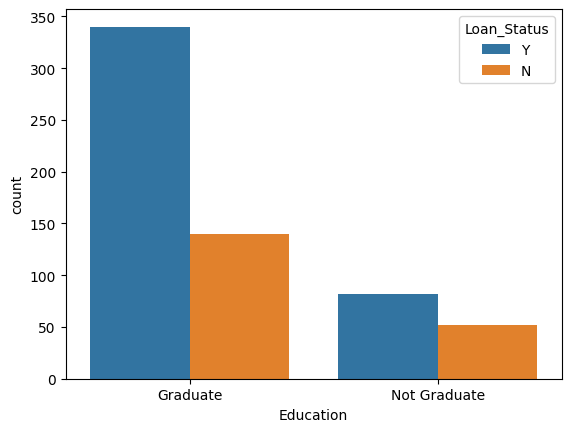

In [15]:
# education vs loan status
sns.countplot(x='Education',hue='Loan_Status',data=loan_data)

<Axes: xlabel='Married', ylabel='count'>

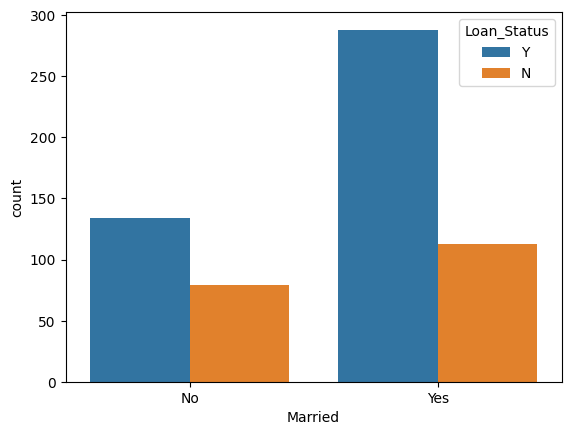

In [16]:
#marital status vs loan status
sns.countplot(x='Married',hue='Loan_Status',data=loan_data)

Model Training

In [17]:
X_scaled_df

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.072991,-0.554487,0.000000,0.279851,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147
1,-0.134412,-0.038732,-0.219273,0.279851,0.411733,0.472343,0.728816,2.240448,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,-0.700208
2,-0.393747,-0.554487,-0.957641,0.279851,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,-0.528362,2.547117,-0.782016,1.428147
3,-0.462062,0.251980,-0.314547,0.279851,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,1.892641,-0.392601,-0.782016,1.428147
4,0.097728,-0.554487,-0.064454,0.279851,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,-0.410130,-0.554487,-0.898095,0.279851,0.411733,-2.117107,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,-0.700208
610,-0.212557,-0.554487,-1.267279,-2.518655,0.411733,0.472343,0.728816,-0.446339,-0.443713,3.322532,-0.528362,-0.392601,-0.782016,-0.700208
611,0.437174,-0.472404,1.269371,0.279851,0.411733,0.472343,0.728816,2.240448,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147
612,0.357064,-0.554487,0.483367,0.279851,0.411733,0.472343,0.728816,-0.446339,2.253710,-0.300975,-0.528362,-0.392601,-0.782016,1.428147


In [47]:
# train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled_df,y,test_size=0.25,stratify=y,random_state=42)


In [48]:
# svm model fit data
classifier=svm.SVC(kernel='linear')

In [49]:
classifier.fit(X_train,y_train)

SVC(kernel='linear')

Model Evalution

In [50]:
# accuracy score on training data
X_train_prediction=classifier.predict(X_train)
training_data_accuracy=accuracy_score(X_train_prediction,y_train)

In [51]:
print(training_data_accuracy)

0.7934782608695652


In [52]:
# accuracy score on test data
X_test_prediction=classifier.predict(X_test)
test_data_accuracy=accuracy_score(X_test_prediction,y_test)

In [53]:
print(test_data_accuracy)

0.8571428571428571


F-1 score


In [54]:
from sklearn.metrics import f1_score

# F1-score on training data
training_f1_score = f1_score(y_train, X_train_prediction)
print(f"F1-score on training data: {training_f1_score:.4f}")

# F1-score on test data
test_f1_score = f1_score(y_test, X_test_prediction)
print(f"F1-score on test data: {test_f1_score:.4f}")

F1-score on training data: 0.8671
F1-score on test data: 0.9052


Trained Model Visualization


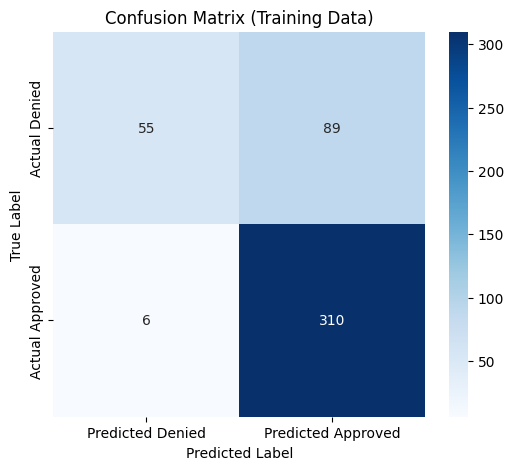

In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# Training data Confusion Matrix
cm_train = confusion_matrix(y_train, X_train_prediction)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Denied', 'Predicted Approved'],
            yticklabels=['Actual Denied', 'Actual Approved'])
plt.title('Confusion Matrix (Training Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

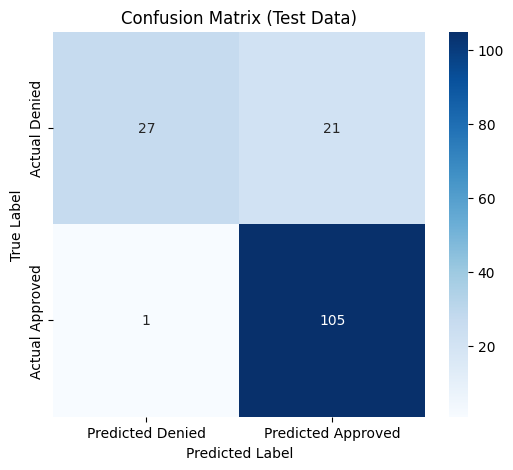

In [59]:
# Test data Confusion Matrix
cm_test = confusion_matrix(y_test, X_test_prediction)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Denied', 'Predicted Approved'],
            yticklabels=['Actual Denied', 'Actual Approved'])
plt.title('Confusion Matrix (Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [62]:
# pickle file
import pickle

# save model
with open('loan_model.pkl', 'wb') as f:
    pickle.dump(classifier, f)

In [ ]:
test_data = {
    "Gender": "Male",
    "Married": "No",
    "Dependents": "3+",
    "Education": "Not Graduate",
    "Self_Employed": "Yes",
    "ApplicantIncome": 600,
    "CoapplicantIncome": 0,
    "LoanAmount": 800,
    "Loan_Amount_Term": 12,
    "Credit_History": 0,
    "Property_Area": "Rural"
}
test_df = pd.DataFrame([test_data])

# Same preprocessing as training
test_df = pd.get_dummies(test_df)

# Match training columns
test_df = test_df.reindex(columns=X.columns, fill_value=0)

# Scale if scaler was used
test_df = scaler.transform(test_df)

prediction = classifier.predict(test_df)



print("Approved" if prediction[0] else "Rejected")